In [1]:
!python --version

Python 3.12.8


In [2]:
import sys
print(sys.version)

3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [3]:
!uv pip list

Package                   Version
------------------------- -----------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.4.22
cffi                      2.0.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.13
ipykernel        

In [4]:
!uv add scikit-learn

Resolved 108 packages in 452ms
Installed 4 packages in 656ms
 + joblib==1.5.3
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + threadpoolctl==3.6.0


In [5]:
import sys
print(sys.executable)

c:\IITG-summer\.venv\Scripts\python.exe


In [17]:
"""
Phase 1: Data Pipeline & Graph Construction
Delhivery Graph-Based Network Intelligence System
 
Builds a directed weighted graph where:
  - Nodes = logistics hubs (source/destination centers)
  - Edges = corridors between hubs
  - Edge weights = median segment_factor (actual/OSRM time ratio)
    stratified by route_type and time_of_day bucket
"""
# Drop rows with clearly erroneous segment_factor (negative or extreme outliers)
# Negative factor = data entry error; >50 = likely one-off anomaly, keep for audit
#loading and basic cleaning 

import pandas as pd
import numpy as np

df = pd.read_csv('delivery_data.csv')

n_before = len(df)
df = df[df["segment_factor"] > 0]
print(f"Dropped {n_before - len(df)} rows with non-positive segment_factor")

 # Fill rare missing hub names with their center IDs
df["source_name"] = df["source_name"].fillna(df["source_center"])
df["destination_name"] = df["destination_name"].fillna(df["destination_center"])



Dropped 2600 rows with non-positive segment_factor


In [ ]:
#feature engineering 
#divide into time buckets -> 6 times of the day night , early morning , morning 
#afternoon , evening , late night 

#sla breach flag -> more than 1.2 factor considered as sla breach 

#factor cap -> we cap the factor at 99th percentile 

# 1. Convert the column to datetime first
df["od_start_time"] = pd.to_datetime(df["od_start_time"])

# 2. Now you can extract the hour
hour = df["od_start_time"].dt.hour

# 3. Create the time buckets
df["time_bucket"] = pd.cut(
    hour,
    bins=[-1, 4, 8, 12, 16, 20, 24],
    labels=["night", "early_morning", "morning", "afternoon", "evening", "late_night"]


)

print("\nOrdered Distribution:")
print(df['time_bucket'].value_counts().sort_index())


#sla breach flag 
df["sla_breach"] = df["segment_factor"] > 1.2
 
# Delay ratio cap for aggregation (remove extreme outliers for edge weight)
df["segment_factor_capped"] = df["segment_factor"].clip(upper=df["segment_factor"].quantile(0.99))
 
print(f"SLA breach rate: {df['sla_breach'].mean():.1%}")
print(f"Route types: {df['route_type'].value_counts().to_dict()}")
print(f"Time buckets: {df['time_bucket'].value_counts().sort_index().to_dict()}")

#feature engineering done -> building corridoor aggregates 


Ordered Distribution:
time_bucket
night            46564
early_morning    26203
morning          13584
afternoon        15121
evening          21537
late_night       19258
Name: count, dtype: int64
SLA breach rate: 84.5%
Route types: {'FTL': 98729, 'Carting': 43538}
Time buckets: {'night': 46564, 'early_morning': 26203, 'morning': 13584, 'afternoon': 15121, 'evening': 21537, 'late_night': 19258}


In [41]:
#rows transform from individual trips to corridor level stats 
#group by source and destination and find median delay factor and other things etc 


#For each (source, destination, route_type, time_bucket) combination,
#compute corridor-level statistics used as graph edge attributes.
#Also build overall (source→dest) edge for the base graph.

grp = df.groupby(["source_center", "destination_center", "route_type", "time_bucket"])
corridor_stats = grp.agg(
        trip_count=("trip_uuid", "nunique"),
        median_factor=("segment_factor_capped", "median"),
        mean_factor=("segment_factor_capped", "mean"),
        p75_factor=("segment_factor_capped", lambda x: x.quantile(0.75)),
        p90_factor=("segment_factor_capped", lambda x: x.quantile(0.90)),
        sla_breach_rate=("sla_breach", "mean"),
        median_actual_time=("segment_actual_time", "median"),
        median_osrm_time=("segment_osrm_time", "median"),
        median_distance=("segment_osrm_distance", "median"),
    ).reset_index()

    # Overall corridor stats (collapse route_type and time_bucket)
overall = df.groupby(["source_center", "destination_center"]).agg(
        trip_count=("trip_uuid", "nunique"),
        median_factor=("segment_factor_capped", "median"),
        mean_factor=("segment_factor_capped", "mean"),
        p75_factor=("segment_factor_capped", lambda x: x.quantile(0.75)),
        p90_factor=("segment_factor_capped", lambda x: x.quantile(0.90)),
        sla_breach_rate=("sla_breach", "mean"),
        median_actual_time=("segment_actual_time", "median"),
        median_osrm_time=("segment_osrm_time", "median"),
        median_distance=("segment_osrm_distance", "median"),
        route_types=("route_type", lambda x: list(x.unique())),
).reset_index()

print(f"\nTotal stratified corridor records: {len(corridor_stats)}")
print(f"Unique source→dest corridors: {len(overall)}")

overall


Total stratified corridor records: 4565
Unique source→dest corridors: 2783


,source_center,destination_center,trip_count,median_factor,mean_factor,p75_factor,p90_factor,sla_breach_rate,median_actual_time,median_osrm_time,median_distance,route_types
0,IND000000AAL,IND411033AAA,18,2.250000,3.069634,2.830303,5.588235,1.000000,31.0,15.0,14.48630,[Carting]
1,IND000000AAQ,IND700028AAB,2,4.939394,5.416667,6.113636,7.518182,1.000000,33.0,7.0,6.92490,[Carting]
2,IND000000AAS,IND783370AAC,9,1.833333,2.580453,2.300000,5.255357,1.000000,35.0,14.5,20.94415,[FTL]
3,IND000000AAZ,IND444203AAA,1,3.208333,4.059096,4.574755,5.394608,1.000000,101.0,24.0,32.86350,[FTL]
4,IND000000AAZ,IND444303AAA,1,2.266184,2.266184,2.377536,2.444348,1.000000,79.5,34.0,46.85345,[FTL]
...,...,...,...,...,...,...,...,...,...,...,...,...
2778,IND854334AAA,IND852118AAA,7,1.333333,1.319728,1.363636,1.389610,1.000000,28.0,21.0,23.87700,[FTL]
2779,IND854334AAA,IND854335AAA,2,1.358974,1.429487,1.538462,1.815385,0.750000,20.0,14.0,17.51180,[FTL]
2780,IND854335AAA,IND852111AAA,17,1.625000,3.292524,5.666667,6.458333,0.964286,26.0,16.0,23.86175,[FTL]
2781,IND854335AAA,IND852118A1B,1,5.187500,5.187500,7.093750,8.237500,1.000000,20.0,9.0,13.36310,[FTL]


In [42]:
#step 4 -> building the graphs
import networkx as nx 
#Directed graph G where:
#Nodes = hub center IDs, with name and state attributes
#Edges = corridors with median_factor, sla_breach_rate, trip_count, distance
#Edge weight = median_factor (higher = more delayed corridor)

#this part is the heart of the whole project 
#rows collapse into a compact graph where every edge carries the median delay 
import re
G = nx.DiGraph()

print("Empty graph created")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Empty graph created
Nodes: 0
Edges: 0


In [43]:
# We need human readable names for each hub ID
# df has source_center (ID) and source_name (readable name)
# example: IND000000ACB → Gurgaon_Bilaspur_HB (Haryana)

# Get names from source side
source_info = df[["source_center", "source_name"]].drop_duplicates("source_center")
source_info.columns = ["center_id", "name"]

# Get names from destination side
dest_info = df[["destination_center", "destination_name"]].drop_duplicates("destination_center")
dest_info.columns = ["center_id", "name"]

# Combine both — some hubs only appear as source, some only as destination
node_info = pd.concat([source_info, dest_info]).drop_duplicates("center_id")

print(f"Total unique hubs found: {len(node_info)}")
node_info.head(10)

Total unique hubs found: 1657


,center_id,name
0,IND388121AAA,Anand_VUNagar_DC (Gujarat)
5,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat)
10,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra)
15,IND400011AAA,LowerParel_CP (Maharashtra)
17,IND562132AAA,Bangalore_Nelmngla_H (Karnataka)
19,IND560099AAB,Bengaluru_Bomsndra_HB (Karnataka)
35,IND141003AAB,Ludhiana_GillChwk_DC (Punjab)
37,IND142026AAA,Jagraon_DC (Punjab)
38,IND141109AAA,Raikot_DC (Punjab)
44,IND362001AAA,Junagadh_DPC (Gujarat)


In [44]:
# Hub names follow this pattern: CityName_SubName (StateName)
# Example: Gurgaon_Bilaspur_HB (Haryana)
# We extract the state from inside the brackets

def extract_state(name):
    match = re.search(r'\(([^)]+)\)', str(name))
    return match.group(1) if match else "Unknown"

# Apply to all hubs
node_info["state"] = node_info["name"].apply(extract_state)

# Verify it worked
print("Sample hub names with extracted states:")
node_info[["center_id", "name", "state"]].head(10)

Sample hub names with extracted states:


,center_id,name,state
0,IND388121AAA,Anand_VUNagar_DC (Gujarat),Gujarat
5,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),Gujarat
10,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),Maharashtra
15,IND400011AAA,LowerParel_CP (Maharashtra),Maharashtra
17,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),Karnataka
19,IND560099AAB,Bengaluru_Bomsndra_HB (Karnataka),Karnataka
35,IND141003AAB,Ludhiana_GillChwk_DC (Punjab),Punjab
37,IND142026AAA,Jagraon_DC (Punjab),Punjab
38,IND141109AAA,Raikot_DC (Punjab),Punjab
44,IND362001AAA,Junagadh_DPC (Gujarat),Gujarat


In [45]:
# Add every hub as a node
# Each node carries: center_id, name, state as attributes

for _, row in node_info.iterrows():
    G.add_node(
        row["center_id"],   # node ID
        name=row["name"],   # human readable name
        state=row["state"]  # which state it's in
    )

print(f"Nodes added to graph: {G.number_of_nodes()}")

# Verify — check what one node looks like
sample_hub = "IND000000ACB"
print(f"\nAttributes for hub {sample_hub}:")
print(G.nodes[sample_hub])

Nodes added to graph: 1657

Attributes for hub IND000000ACB:
{'name': 'Gurgaon_Bilaspur_HB (Haryana)', 'state': 'Haryana'}


In [47]:
# Add every corridor as a directed edge
# Each edge carries all the statistics we computed in Step 3

for _, row in overall.iterrows():
    G.add_edge(
        row["source_center"],       # edge starts here
        row["destination_center"],  # edge ends here
        
        weight           = row["median_factor"],       # primary weight — used by graph algorithms
        median_factor    = row["median_factor"],       # typical delay ratio
        mean_factor      = row["mean_factor"],         # average delay ratio
        p75_factor       = row["p75_factor"],          # 75% of trips are below this
        p90_factor       = row["p90_factor"],          # 90% of trips are below this
        sla_breach_rate  = row["sla_breach_rate"],     # % of trips that were late
        trip_count       = row["trip_count"],          # how busy this corridor is
        median_actual_time = row["median_actual_time"],# typical actual hours
        median_osrm_time   = row["median_osrm_time"],  # what OSRM predicted
        median_distance    = row["median_distance"],   # km
        route_types        = str(row["route_types"]),  # FTL, Carting, or both
    )

print(f"Edges added to graph: {G.number_of_edges()}")

# Verify — check what one edge looks like
print("\nAttributes for Mumbai corridor:")
print(G.edges["IND000000ACB", list(G.successors("IND000000ACB"))[0]])

Edges added to graph: 2783

Attributes for Mumbai corridor:
{'weight': 1.5454545454545454, 'median_factor': 1.5454545454545454, 'mean_factor': 2.2236943355771177, 'p75_factor': 2.4, 'p90_factor': 3.6857142857142855, 'sla_breach_rate': 0.8394160583941606, 'trip_count': 23, 'median_actual_time': 17.0, 'median_osrm_time': 10.0, 'median_distance': 10.943700000000002, 'route_types': "['Carting']"}


In [48]:
# Full summary of the graph we just built

wcc = list(nx.weakly_connected_components(G))

print("─" * 40)
print("         GRAPH SUMMARY")
print("─" * 40)
print(f"Nodes (hubs)       : {G.number_of_nodes():,}")
print(f"Edges (corridors)  : {G.number_of_edges():,}")
print(f"Directed           : {G.is_directed()}")
print(f"Density            : {nx.density(G):.6f}")
print(f"Connected components: {len(wcc)}")
print(f"Largest component  : {max(len(c) for c in wcc):,} nodes")
print("─" * 40)

────────────────────────────────────────
         GRAPH SUMMARY
────────────────────────────────────────
Nodes (hubs)       : 1,657
Edges (corridors)  : 2,783
Directed           : True
Density            : 0.001014
Connected components: 64
Largest component  : 1,353 nodes
────────────────────────────────────────


In [50]:
# Things to verify the graph was built correctly

# 1. Check a specific hub's connections
hub = "IND000000ACB"
print(f"Hub: {G.nodes[hub]['name']}")
print(f"Sends to {G.out_degree(hub)} destinations")
print(f"Receives from {G.in_degree(hub)} sources")

# 2. See all corridors leaving this hub
print(f"\nAll outgoing corridors from this hub:")
for neighbor in G.successors(hub):
    edge = G.edges[hub, neighbor]
    print(f"  → {G.nodes[neighbor]['name'][:30]:<30}  factor: {edge['median_factor']:.2f}  sla_breach: {edge['sla_breach_rate']:.0%}")

import os

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Save as GraphML — standard format that preserves all node and edge attributes
nx.write_graphml(G, f"{OUT_DIR}/delivery_network.graphml")

print(f"Graph saved to {OUT_DIR}/delivery_network.graphml")
print(f"You can reload it later with: G = nx.read_graphml('outputs/delivery_network.graphml')")

Hub: Gurgaon_Bilaspur_HB (Haryana)
Sends to 49 destinations
Receives from 45 sources

All outgoing corridors from this hub:
  → Delhi_PunjabiB_L (Delhi)        factor: 1.55  sla_breach: 84%
  → Delhi_Lajpat_IP (Delhi)         factor: 1.76  sla_breach: 92%
  → Delhi_Kishangarh_DPC (Delhi)    factor: 1.56  sla_breach: 72%
  → Delhi_Kapshera_L (Delhi)        factor: 1.50  sla_breach: 76%
  → Delhi_Nangli_IP (Delhi)         factor: 1.78  sla_breach: 82%
  → Delhi_Nangli_L (Delhi)          factor: 1.56  sla_breach: 98%
  → Delhi_Wazirpur_L (Delhi)        factor: 1.50  sla_breach: 79%
  → Delhi_Mayapuri_PC (Delhi)       factor: 1.38  sla_breach: 68%
  → Delhi_Rohini_DPC (Delhi)        factor: 1.45  sla_breach: 73%
  → Delhi_Patparganj_DPC (Delhi)    factor: 1.33  sla_breach: 57%
  → Delhi_Jhilmil_L (Delhi)         factor: 1.38  sla_breach: 56%
  → Faridabad_Mthurard_L (Haryana)  factor: 1.68  sla_breach: 84%
  → FBD_Balabhgarh_DPC (Haryana)    factor: 1.62  sla_breach: 87%
  → GGN_DPC (Harya

In [53]:
## Step 5: Compute Node Metrics & Bottleneck Ranking

#For every hub in the graph we compute 4 metrics:
#1. **Betweenness centrality** — how many routes pass through this hub
#2. **In/Out degree** — how many corridors connect to this hub
#3. **Average delay factor** — how delayed are trips leaving this hub
#4. **SLA breach rate** — what % of outgoing trips are late

#Then we combine them into one **bottleneck score** to rank every hub.

In [54]:
# The full graph has 64 weakly connected components
# Small isolated components (2-3 hubs) skew centrality calculations
# We compute betweenness only on the largest component

all_components = list(nx.weakly_connected_components(G))

print(f"Total components: {len(all_components)}")
print(f"Sizes: {sorted([len(c) for c in all_components], reverse=True)[:10]}")

# Extract largest
largest_wcc = max(all_components, key=len)
G_main = G.subgraph(largest_wcc).copy()

print(f"\nLargest component has {G_main.number_of_nodes()} nodes and {G_main.number_of_edges()} edges")
print(f"This covers {len(largest_wcc)/G.number_of_nodes():.1%} of all hubs")

Total components: 64
Sizes: [1353, 28, 20, 19, 13, 10, 10, 9, 7, 7]

Largest component has 1353 nodes and 2463 edges
This covers 81.7% of all hubs


In [55]:
# In-degree  = how many hubs send TO this hub
# Out-degree = how many hubs this hub sends TO

in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Weighted strength = sum of all edge weights connected to this hub
# Higher strength = more total delay flowing through this hub
in_strength  = {
    n: sum(d["weight"] for _, _, d in G.in_edges(n, data=True)) 
    for n in G.nodes()
}
out_strength = {
    n: sum(d["weight"] for _, _, d in G.out_edges(n, data=True)) 
    for n in G.nodes()
}

print("Degree metrics computed")
print(f"\nTop 5 hubs by out-degree (most outgoing corridors):")
top_out = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:5]
for hub_id, deg in top_out:
    print(f"  {G.nodes[hub_id]['name'][:40]:<40}  out_degree: {deg}")

Degree metrics computed

Top 5 hubs by out-degree (most outgoing corridors):
  Gurgaon_Bilaspur_HB (Haryana)             out_degree: 49
  Bangalore_Nelmngla_H (Karnataka)          out_degree: 35
  Bhiwandi_Mankoli_HB (Maharashtra)         out_degree: 29
  Chandigarh_Mehmdpur_H (Punjab)            out_degree: 29
  Hyderabad_Shamshbd_H (Telangana)          out_degree: 27


In [56]:
# Betweenness centrality = how often this hub sits on the 
# shortest path between two other hubs
# 
# High betweenness = removing this hub disconnects many routes
# We use k=500 samples for speed — exact computation would take hours
# on a graph this size

print("Computing betweenness centrality (this takes ~30 seconds)...")

betweenness = nx.betweenness_centrality(
    G_main,
    weight="weight",      # use delay factor as edge weight
    normalized=True,      # scale between 0 and 1
    k=min(500, G_main.number_of_nodes())   # sample 500 nodes
)

print("Done!")
print(f"\nTop 5 hubs by betweenness centrality:")
top_btw = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
for hub_id, score in top_btw:
    print(f"  {G.nodes[hub_id]['name'][:40]:<40}  betweenness: {score:.4f}")

Computing betweenness centrality (this takes ~30 seconds)...
Done!

Top 5 hubs by betweenness centrality:
  Gurgaon_Bilaspur_HB (Haryana)             betweenness: 0.3506
  Bangalore_Nelmngla_H (Karnataka)          betweenness: 0.2337
  Kolkata_Dankuni_HB (West Bengal)          betweenness: 0.1266
  Hyderabad_Shamshbd_H (Telangana)          betweenness: 0.1141
  Bhiwandi_Mankoli_HB (Maharashtra)         betweenness: 0.0858


In [57]:
# For each hub — what does the typical outgoing trip look like?

avg_out_factor = {}   # average delay factor of outgoing corridors
avg_in_factor  = {}   # average delay factor of incoming corridors
avg_out_sla    = {}   # average SLA breach rate of outgoing corridors

for n in G.nodes():
    
    # Outgoing edges
    out_edges = [d for _, _, d in G.out_edges(n, data=True)]
    avg_out_factor[n] = np.mean([d["weight"] for d in out_edges])         if out_edges else 0
    avg_out_sla[n]    = np.mean([d["sla_breach_rate"] for d in out_edges]) if out_edges else 0
    
    # Incoming edges
    in_edges = [d for _, _, d in G.in_edges(n, data=True)]
    avg_in_factor[n]  = np.mean([d["weight"] for d in in_edges])          if in_edges else 0

print("Delay and SLA metrics computed")
print(f"\nTop 5 hubs by average outgoing delay factor:")
top_delay = sorted(avg_out_factor.items(), key=lambda x: x[1], reverse=True)[:5]
for hub_id, factor in top_delay:
    print(f"  {G.nodes[hub_id]['name'][:40]:<40}  avg_factor: {factor:.2f}")

Delay and SLA metrics computed

Top 5 hubs by average outgoing delay factor:
  Mariani_Mainroad_D (Assam)                avg_factor: 11.60
  Simlapal_Central_D_1 (West Bengal)        avg_factor: 11.60
  Helencha_ColnyDPP_D (West Bengal)         avg_factor: 11.60
  Ranaghat_ArickDPP_D (West Bengal)         avg_factor: 11.60
  Kanpur_Central_D_7 (Uttar Pradesh)        avg_factor: 11.60


In [58]:
# Bring all metrics together into one clean table
# One row per hub

nodes = list(G.nodes())

node_metrics = pd.DataFrame({
    "hub_id"               : nodes,
    "hub_name"             : [G.nodes[n].get("name", n) for n in nodes],
    "state"                : [G.nodes[n].get("state", "Unknown") for n in nodes],
    "in_degree"            : [in_degree[n] for n in nodes],
    "out_degree"           : [out_degree[n] for n in nodes],
    "in_strength"          : [in_strength[n] for n in nodes],
    "out_strength"         : [out_strength[n] for n in nodes],
    "betweenness_centrality" : [betweenness.get(n, 0) for n in nodes],
    "avg_outgoing_factor"  : [avg_out_factor[n] for n in nodes],
    "avg_incoming_factor"  : [avg_in_factor[n] for n in nodes],
    "avg_outgoing_sla_breach" : [avg_out_sla[n] for n in nodes],
    "in_wcc"               : [1 if n in largest_wcc else 0 for n in nodes],
})

print(f"Node metrics table shape: {node_metrics.shape}")
node_metrics.head()

Node metrics table shape: (1657, 12)


,hub_id,hub_name,state,in_degree,out_degree,in_strength,out_strength,betweenness_centrality,avg_outgoing_factor,avg_incoming_factor,avg_outgoing_sla_breach,in_wcc
0,IND388121AAA,Anand_VUNagar_DC (Gujarat),Gujarat,1,1,4.250000,1.392308,0.000617,1.392308,4.250000,0.703704,1
1,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),Gujarat,1,1,1.392308,1.833333,0.000000,1.833333,1.392308,0.815385,1
2,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),Maharashtra,29,29,58.026581,58.512986,0.085842,2.017689,2.000917,0.933553,1
3,IND400011AAA,LowerParel_CP (Maharashtra),Maharashtra,2,2,6.531944,4.877778,0.000616,2.438889,3.265972,0.981308,1
4,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),Karnataka,36,35,55.851705,54.033654,0.233726,1.543819,1.551436,0.774111,1


In [59]:
# Each metric is on a different scale
# betweenness is 0 to 1
# avg_outgoing_factor could be 1 to 10
# out_degree could be 1 to 49
#
# We normalize everything to 0-1 first
# then combine with weights into one score

cols_to_normalize = [
    "betweenness_centrality",
    "avg_outgoing_factor",
    "avg_outgoing_sla_breach",
    "out_degree"
]

for col in cols_to_normalize:
    min_val = node_metrics[col].min()
    max_val = node_metrics[col].max()
    node_metrics[f"{col}_norm"] = (node_metrics[col] - min_val) / (max_val - min_val + 1e-9)

# Bottleneck score — weighted combination
# Betweenness gets highest weight because a central hub
# that delays affects ALL downstream routes, not just its own
node_metrics["bottleneck_score"] = (
    0.35 * node_metrics["betweenness_centrality_norm"] +
    0.25 * node_metrics["avg_outgoing_factor_norm"]    +
    0.25 * node_metrics["avg_outgoing_sla_breach_norm"]+
    0.15 * node_metrics["out_degree_norm"]
)

# Rank from worst to best
node_metrics = node_metrics.sort_values("bottleneck_score", ascending=False).reset_index(drop=True)
node_metrics["bottleneck_rank"] = node_metrics.index + 1

print("Bottleneck scores computed and ranked")

Bottleneck scores computed and ranked


In [60]:
# The most important output of Phase 1
# These are the hubs the strategy memo will focus on

cols_to_show = [
    "bottleneck_rank",
    "hub_name",
    "state",
    "in_degree",
    "out_degree",
    "betweenness_centrality",
    "avg_outgoing_factor",
    "avg_outgoing_sla_breach",
    "bottleneck_score"
]

print("TOP 10 BOTTLENECK HUBS")
print("=" * 80)
node_metrics[cols_to_show].head(10)

TOP 10 BOTTLENECK HUBS


,bottleneck_rank,hub_name,state,in_degree,out_degree,betweenness_centrality,avg_outgoing_factor,avg_outgoing_sla_breach,bottleneck_score
0,1,Gurgaon_Bilaspur_HB (Haryana),Haryana,45,49,0.350590,1.599466,0.794141,0.733007
1,2,Bangalore_Nelmngla_H (Karnataka),Karnataka,36,35,0.233726,1.543819,0.774111,0.567275
2,3,Helencha_ColnyDPP_D (West Bengal),West Bengal,1,1,0.001636,11.600000,1.000000,0.504694
3,4,Simlapal_Central_D_1 (West Bengal),West Bengal,1,1,0.000000,11.600000,1.000000,0.503061
4,5,RampuraPhul_DC (Punjab),Punjab,1,1,0.000000,11.600000,1.000000,0.503061
5,6,Mariani_Mainroad_D (Assam),Assam,1,1,0.000000,11.600000,1.000000,0.503061
6,7,Ranaghat_ArickDPP_D (West Bengal),West Bengal,1,1,0.000000,11.600000,1.000000,0.503061
7,8,Mahasamund_RajpurRD_D (Chhattisgarh),Chhattisgarh,1,1,0.000000,11.600000,1.000000,0.503061
8,9,Jabalpur (Madhya Pradesh),Madhya Pradesh,1,1,0.000000,11.600000,1.000000,0.503061
9,10,Faridabad_Old (Haryana),Haryana,1,1,0.000000,11.600000,1.000000,0.503061


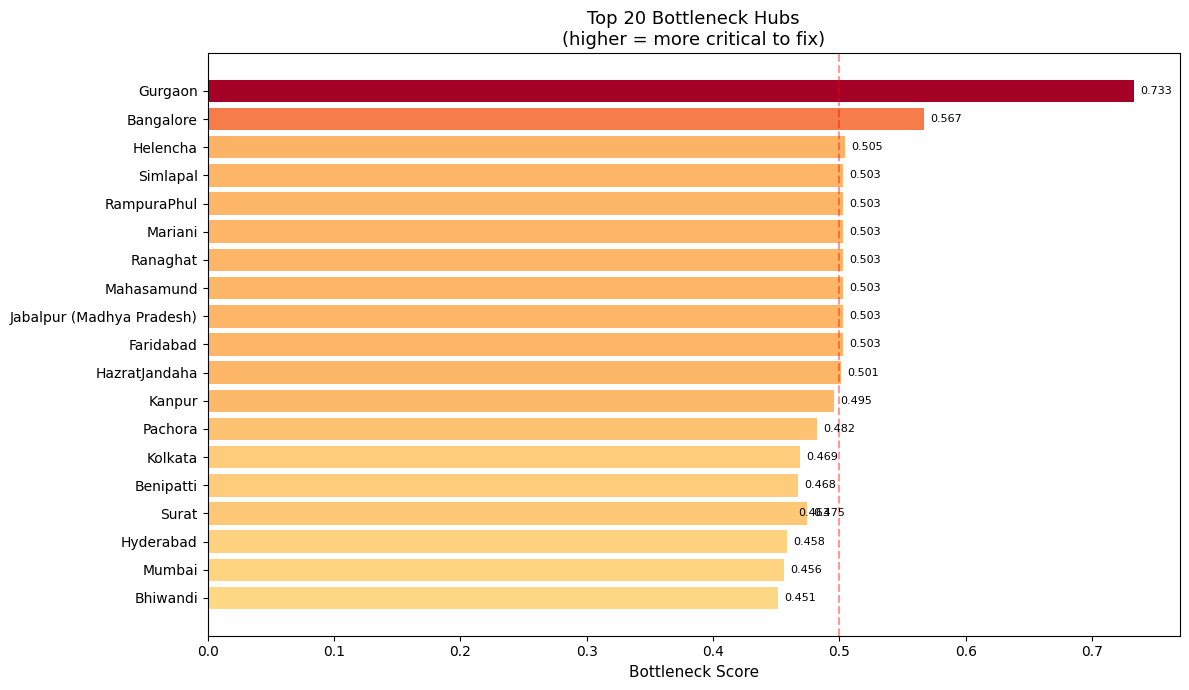

In [61]:
import matplotlib.pyplot as plt

top20 = node_metrics.head(20).copy()
top20["short_name"] = top20["hub_name"].apply(lambda x: x.split("_")[0])

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top20["short_name"][::-1],
    top20["bottleneck_score"][::-1],
    color=plt.cm.RdYlGn_r(top20["bottleneck_score"][::-1] / top20["bottleneck_score"].max())
)

ax.set_xlabel("Bottleneck Score", fontsize=11)
ax.set_title("Top 20 Bottleneck Hubs\n(higher = more critical to fix)", fontsize=13)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='High risk threshold')

for bar, score in zip(bars, top20["bottleneck_score"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{score:.3f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [62]:
import os

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

node_metrics.to_csv(f"{OUT_DIR}/node_metrics.csv", index=False)

print(f"Saved node_metrics.csv")
print(f"Shape: {node_metrics.shape}")
print(f"\nTop 5 bottleneck hubs:")
for _, row in node_metrics.head(5).iterrows():
    print(f"  #{int(row['bottleneck_rank'])}  {row['hub_name'][:40]:<40}  score: {row['bottleneck_score']:.3f}")

Saved node_metrics.csv
Shape: (1657, 18)

Top 5 bottleneck hubs:
  #1  Gurgaon_Bilaspur_HB (Haryana)             score: 0.733
  #2  Bangalore_Nelmngla_H (Karnataka)          score: 0.567
  #3  Helencha_ColnyDPP_D (West Bengal)         score: 0.505
  #4  Simlapal_Central_D_1 (West Bengal)        score: 0.503
  #5  RampuraPhul_DC (Punjab)                   score: 0.503


In [64]:
# 1. Calculate the degree of each node
# For directed graphs, 'degree' is the sum of incoming and outgoing connections
degrees = dict(G.degree())

# 2. Find the node with the most connections
top_node_id = max(degrees, key=degrees.get)
top_node_name = G.nodes[top_node_id].get('name', 'Unknown')
top_node_degree = degrees[top_node_id]

print(f"The node with the most connections is: {top_node_name}")
print(f"ID: {top_node_id}")
print(f"Number of connections: {top_node_degree}")


The node with the most connections is: Gurgaon_Bilaspur_HB (Haryana)
ID: IND000000ACB
Number of connections: 94


In [66]:
## Step 6: Export All Artifacts

import os
import json

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Output folder ready: {OUT_DIR}")

Output folder ready: outputs


In [67]:
node_metrics.to_csv(f"{OUT_DIR}/node_metrics.csv", index=False)

print(f"Saved node_metrics.csv")
print(f"Shape : {node_metrics.shape}")
print(f"Columns: {node_metrics.columns.tolist()}")
print()
print("Preview:")
node_metrics.head(3)

Saved node_metrics.csv
Shape : (1657, 18)
Columns: ['hub_id', 'hub_name', 'state', 'in_degree', 'out_degree', 'in_strength', 'out_strength', 'betweenness_centrality', 'avg_outgoing_factor', 'avg_incoming_factor', 'avg_outgoing_sla_breach', 'in_wcc', 'betweenness_centrality_norm', 'avg_outgoing_factor_norm', 'avg_outgoing_sla_breach_norm', 'out_degree_norm', 'bottleneck_score', 'bottleneck_rank']

Preview:


,hub_id,hub_name,state,in_degree,out_degree,in_strength,out_strength,betweenness_centrality,avg_outgoing_factor,avg_incoming_factor,avg_outgoing_sla_breach,in_wcc,betweenness_centrality_norm,avg_outgoing_factor_norm,avg_outgoing_sla_breach_norm,out_degree_norm,bottleneck_score,bottleneck_rank
0,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),Haryana,45,49,69.316018,78.373821,0.350590,1.599466,1.540356,0.794141,1,1.000000,0.137885,0.794141,1.000000,0.733007,1
1,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),Karnataka,36,35,55.851705,54.033654,0.233726,1.543819,1.551436,0.774111,1,0.666664,0.133088,0.774111,0.714286,0.567275,2
2,IND743270AAA,Helencha_ColnyDPP_D (West Bengal),West Bengal,1,1,2.100000,11.600000,0.001636,11.600000,2.100000,1.000000,1,0.004666,1.000000,1.000000,0.020408,0.504694,3


In [69]:
overall.to_csv(f"{OUT_DIR}/corridor_aggregates.csv", index=False)

print(f"Saved corridor_aggregates.csv")
print(f"Shape : {overall.shape}")
print()
print("Preview:")
overall.head(3)

Saved corridor_aggregates.csv
Shape : (2783, 12)

Preview:


,source_center,destination_center,trip_count,median_factor,mean_factor,p75_factor,p90_factor,sla_breach_rate,median_actual_time,median_osrm_time,median_distance,route_types
0,IND000000AAL,IND411033AAA,18,2.250000,3.069634,2.830303,5.588235,1.0,31.0,15.0,14.48630,[Carting]
1,IND000000AAQ,IND700028AAB,2,4.939394,5.416667,6.113636,7.518182,1.0,33.0,7.0,6.92490,[Carting]
2,IND000000AAS,IND783370AAC,9,1.833333,2.580453,2.300000,5.255357,1.0,35.0,14.5,20.94415,[FTL]


In [70]:
corridor_stats.to_csv(f"{OUT_DIR}/corridor_stratified.csv", index=False)

print(f"Saved corridor_stratified.csv")
print(f"Shape : {corridor_stats.shape}")
print()
print("Preview:")
corridor_stats.head(3)

Saved corridor_stratified.csv
Shape : (4565, 13)

Preview:


,source_center,destination_center,route_type,time_bucket,trip_count,median_factor,mean_factor,p75_factor,p90_factor,sla_breach_rate,median_actual_time,median_osrm_time,median_distance
0,IND000000AAL,IND411033AAA,Carting,night,1,1.950000,1.950000,2.058333,2.123333,1.0,26.0,13.5,14.02360
1,IND000000AAL,IND411033AAA,Carting,early_morning,1,3.197436,3.197436,3.829487,4.208718,1.0,43.5,14.0,14.22935
2,IND000000AAL,IND411033AAA,Carting,morning,2,2.333333,2.379329,2.471591,2.570455,1.0,30.0,13.0,13.83505


In [71]:
nx.write_graphml(G, f"{OUT_DIR}/delivery_network.graphml")

print(f"Saved delivery_network.graphml")
print(f"Nodes : {G.number_of_nodes():,}")
print(f"Edges : {G.number_of_edges():,}")
print()
print("To reload this graph in any future notebook:")
print("  G = nx.read_graphml('outputs/delivery_network.graphml')")

Saved delivery_network.graphml
Nodes : 1,657
Edges : 2,783

To reload this graph in any future notebook:
  G = nx.read_graphml('outputs/delivery_network.graphml')


In [72]:
# Split the cleaned df back into train and test
# These are used in Phase 3 for the ETA prediction model

train_df = df[df["data"] == "training"].copy()
test_df  = df[df["data"] == "test"].copy()

train_df.to_csv(f"{OUT_DIR}/train_clean.csv", index=False)
test_df.to_csv(f"{OUT_DIR}/test_clean.csv",  index=False)

print(f"Saved train_clean.csv  → {len(train_df):,} rows")
print(f"Saved test_clean.csv   → {len(test_df):,} rows")
print()
print(f"Train/test split: {len(train_df)/len(df):.0%} / {len(test_df)/len(df):.0%}")

Saved train_clean.csv  → 103,049 rows
Saved test_clean.csv   → 39,218 rows

Train/test split: 72% / 28%


In [73]:
# A small summary file with the key numbers
# Used directly in the Phase 5 strategy memo

wcc_sizes = sorted([len(c) for c in all_components], reverse=True)

summary = {
    "graph": {
        "num_nodes"          : G.number_of_nodes(),
        "num_edges"          : G.number_of_edges(),
        "density"            : round(nx.density(G), 6),
        "num_components"     : len(all_components),
        "largest_component"  : max(wcc_sizes),
    },
    "data": {
        "total_rows"         : len(df),
        "total_trips"        : int(df["trip_uuid"].nunique()),
        "sla_breach_rate"    : round(float(df["sla_breach"].mean()), 4),
        "median_factor"      : round(float(df["segment_factor"].median()), 4),
        "route_type_split"   : df["route_type"].value_counts().to_dict(),
    },
    "top5_bottleneck_hubs"   : node_metrics[[
                                    "hub_id", 
                                    "hub_name", 
                                    "state", 
                                    "bottleneck_score"
                               ]].head(5).to_dict("records"),
}

with open(f"{OUT_DIR}/graph_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved graph_summary.json")
print()
print("Contents:")
print(json.dumps(summary, indent=2))

Saved graph_summary.json

Contents:
{
  "graph": {
    "num_nodes": 1657,
    "num_edges": 2783,
    "density": 0.001014,
    "num_components": 64,
    "largest_component": 1353
  },
  "data": {
    "total_rows": 142267,
    "total_trips": 14817,
    "sla_breach_rate": 0.8447,
    "median_factor": 1.7,
    "route_type_split": {
      "FTL": 98729,
      "Carting": 43538
    }
  },
  "top5_bottleneck_hubs": [
    {
      "hub_id": "IND000000ACB",
      "hub_name": "Gurgaon_Bilaspur_HB (Haryana)",
      "state": "Haryana",
      "bottleneck_score": 0.7330065830351155
    },
    {
      "hub_id": "IND562132AAA",
      "hub_name": "Bangalore_Nelmngla_H (Karnataka)",
      "state": "Karnataka",
      "bottleneck_score": 0.5672749955169595
    },
    {
      "hub_id": "IND743270AAA",
      "hub_name": "Helencha_ColnyDPP_D (West Bengal)",
      "state": "West Bengal",
      "bottleneck_score": 0.5046942959291996
    },
    {
      "hub_id": "IND722151AAA",
      "hub_name": "Simlapal_Central_

In [74]:
print("=" * 50)
print("  PHASE 1 COMPLETE — FILES SAVED")
print("=" * 50)

files = [
    "node_metrics.csv",
    "corridor_aggregates.csv",
    "corridor_stratified.csv",
    "delivery_network.graphml",
    "train_clean.csv",
    "test_clean.csv",
    "graph_summary.json",
]

for f in files:
    path = f"{OUT_DIR}/{f}"
    size = os.path.getsize(path)
    exists = "✓" if os.path.exists(path) else "✗"
    print(f"  {exists}  {f:<35} {size/1024:.1f} KB")

print()
print("These files are the input to every future phase.")
print("You never need to rerun Phase 1 again.")

  PHASE 1 COMPLETE — FILES SAVED
  ✓  node_metrics.csv                    373.8 KB
  ✓  corridor_aggregates.csv             360.4 KB
  ✓  corridor_stratified.csv             611.5 KB
  ✓  delivery_network.graphml            1580.8 KB
  ✓  train_clean.csv                     41257.5 KB
  ✓  test_clean.csv                      15506.3 KB
  ✓  graph_summary.json                  1.2 KB

These files are the input to every future phase.
You never need to rerun Phase 1 again.
